In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Importar el Data Set
dataSet = pd.read_csv("USA Housing Dataset.csv")

In [3]:
dataSet.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


In [4]:
dataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4140 non-null   object 
 1   price          4140 non-null   float64
 2   bedrooms       4140 non-null   float64
 3   bathrooms      4140 non-null   float64
 4   sqft_living    4140 non-null   int64  
 5   sqft_lot       4140 non-null   int64  
 6   floors         4140 non-null   float64
 7   waterfront     4140 non-null   int64  
 8   view           4140 non-null   int64  
 9   condition      4140 non-null   int64  
 10  sqft_above     4140 non-null   int64  
 11  sqft_basement  4140 non-null   int64  
 12  yr_built       4140 non-null   int64  
 13  yr_renovated   4140 non-null   int64  
 14  street         4140 non-null   object 
 15  city           4140 non-null   object 
 16  statezip       4140 non-null   object 
 17  country        4140 non-null   object 
dtypes: float

In [5]:
dataSet["country"].unique()

array(['USA'], dtype=object)

In [6]:
dataSet["bedrooms"].sort_values().unique()

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [7]:
dataSet["condition"].sort_values().unique()

array([1, 2, 3, 4, 5])

In [8]:
dataSet["price"].sort_values().astype(int).unique()

array([       0,     7800,    80000, ...,  7062500, 12899000, 26590000],
      shape=(1625,))

In [9]:
dataSet[dataSet["price"] == 0].shape

(49, 18)

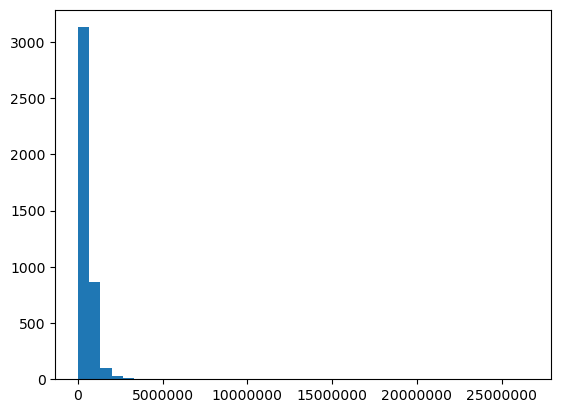

In [10]:
plt.hist(dataSet["price"], bins = 40)
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.show()

In [11]:
dataSet.price.describe()

count    4.140000e+03
mean     5.530629e+05
std      5.836865e+05
min      0.000000e+00
25%      3.200000e+05
50%      4.600000e+05
75%      6.591250e+05
max      2.659000e+07
Name: price, dtype: float64

In [12]:
dataSet[dataSet["price"] == 26590000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
3890,2014-07-03 00:00:00,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA


In [13]:
#Analizar la Desviacion Estandar
desv_stn = dataSet["price"].std() / dataSet["price"].mean()
desv_stn
#Si desv_stn < 0.5 --> baja dispersion
#Si desv_stn - 0.5 - 1 --> moderada
#Si desv_stn => 1 --> alta dispersion

np.float64(1.0553708741140801)

In [14]:
dataSet["price"].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     320000.00
0.50     460000.00
0.75     659125.00
0.90     907750.00
0.95    1185250.95
Name: price, dtype: float64

In [15]:
dataSet[dataSet["price"] > 1185251].shape

(207, 18)

In [16]:
residuo = 207/4193
residuo

0.049367994276174575

In [17]:
dataFiltered = dataSet[dataSet["price"] <= 1185251]

In [18]:
dataFiltered.shape

(3933, 18)

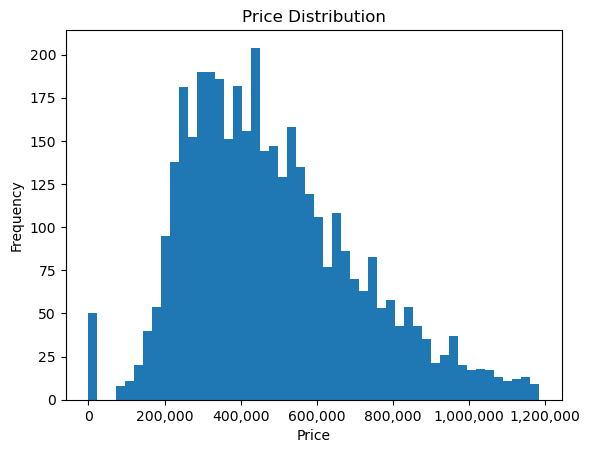

In [19]:
import matplotlib.ticker as mticker

plt.hist(dataFiltered["price"], bins = 50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [20]:
(dataFiltered[dataFiltered["price"] == 0]).shape

(49, 18)

In [21]:
dataFiltered.shape

(3933, 18)

In [22]:
dataFiltered = dataFiltered[dataFiltered["price"] > 0]

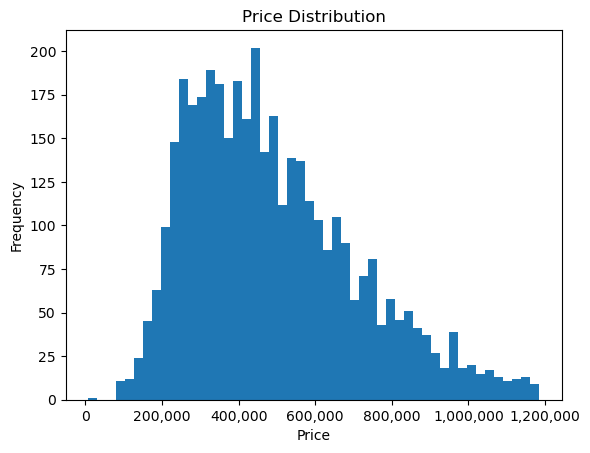

In [23]:
plt.hist(dataFiltered["price"], bins = 50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [24]:
dataFiltered["price"].sort_values().head(20)

3891      7800.000000
759      80000.000000
1127     83000.000000
3947     83300.000000
3955     83300.000000
3885     84350.000000
3965     87500.000000
823      90000.000000
128      90000.000000
1743    100000.000000
3485    100000.000000
3183    100000.000000
3309    102500.000000
3927    107500.000000
3987    108333.333333
69      110000.000000
1869    110000.000000
448     110700.000000
3653    115000.000000
3893    117833.333333
Name: price, dtype: float64

In [25]:
dataFiltered = dataFiltered[dataFiltered["price"] > 9000]

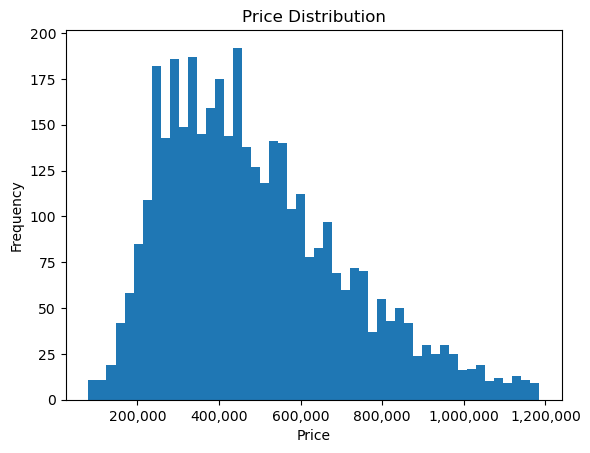

In [26]:
plt.hist(dataFiltered["price"], bins = 50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

In [27]:
dataFiltered["price"].sort_values().head(10)

759      80000.0
1127     83000.0
3947     83300.0
3955     83300.0
3885     84350.0
3965     87500.0
823      90000.0
128      90000.0
3485    100000.0
3183    100000.0
Name: price, dtype: float64

In [28]:
dataFiltered.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA
5,2014-05-10 00:00:00,320000.0,3.0,2.50,2130,6969,2.0,0,0,3,2130,0,2003,0,Cedar to Green River Trail,Maple Valley,WA 98038,USA
6,2014-05-10 00:00:00,875000.0,4.0,2.00,2520,6000,1.0,0,0,3,1400,1120,1921,2007,6521 Fremont Ave N,Seattle,WA 98103,USA
7,2014-05-10 00:00:00,265000.0,4.0,1.00,1940,9533,1.0,0,0,3,1080,860,1962,2003,9908 S 210th Pl,Kent,WA 98031,USA
8,2014-05-10 00:00:00,394950.0,3.0,2.50,1350,1250,3.0,0,0,3,1270,80,2006,0,5940 California Ave SW,Seattle,WA 98136,USA
9,2014-05-11 00:00:00,842500.0,4.0,2.50,2160,5298,2.5,0,0,4,2160,0,1902,0,906 17th Ave,Seattle,WA 98122,USA
10,2014-05-11 00:00:00,368000.0,3.0,2.50,1370,1350,2.0,0,0,3,1010,360,2007,0,5411 Fauntleroy Way SW,Seattle,WA 98136,USA


In [29]:
dataFiltered = dataFiltered.drop(columns = ["country", "statezip", "street"])

In [30]:
dataFiltered.head(3)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,Seattle
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,Carnation
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,Seattle


In [31]:
dataFiltered = dataFiltered.drop(columns = ["date", "sqft_living", "waterfront", "view", "sqft_above", "sqft_basement", "yr_built", "yr_renovated"])

In [32]:
dataFiltered.head(3)

,price,bedrooms,bathrooms,sqft_lot,floors,condition,city
0,376000.0,3.0,2.00,1384,3.0,3,Seattle
1,800000.0,4.0,3.25,159430,2.0,3,Carnation
3,324000.0,3.0,2.25,904,2.0,3,Seattle


In [33]:
dataFiltered["city"].sort_values().unique()

array(['Algona', 'Auburn', 'Beaux Arts Village', 'Bellevue',
       'Black Diamond', 'Bothell', 'Burien', 'Carnation', 'Clyde Hill',
       'Covington', 'Des Moines', 'Duvall', 'Enumclaw', 'Fall City',
       'Federal Way', 'Issaquah', 'Kenmore', 'Kent', 'Kirkland',
       'Lake Forest Park', 'Maple Valley', 'Medina', 'Mercer Island',
       'Milton', 'Newcastle', 'Normandy Park', 'North Bend', 'Pacific',
       'Preston', 'Ravensdale', 'Redmond', 'Renton', 'Sammamish',
       'SeaTac', 'Seattle', 'Shoreline', 'Skykomish', 'Snoqualmie',
       'Snoqualmie Pass', 'Tukwila', 'Vashon', 'Woodinville',
       'Yarrow Point'], dtype=object)

In [34]:
dataFiltered.groupby("city")["price"].median().sort_values(ascending=False)

city
Clyde Hill            936000.00
Mercer Island         835500.00
Beaux Arts Village    745000.00
Sammamish             662500.00
Bellevue              662500.00
Redmond               636500.00
Ravensdale            605500.00
Newcastle             595000.00
Fall City             563500.00
Preston               562450.00
Woodinville           558512.50
Issaquah              558500.00
Snoqualmie            545000.00
Snoqualmie Pass       525000.00
Kirkland              510000.00
Yarrow Point          491675.00
Seattle               475000.00
Black Diamond         454000.00
Bothell               450500.00
Lake Forest Park      450000.00
Vashon                449000.00
Normandy Park         447500.00
Kenmore               425000.00
Carnation             420850.00
Duvall                415000.00
North Bend            397000.00
Shoreline             355150.00
Renton                345000.00
Maple Valley          322500.00
Burien                289968.75
Enumclaw              289000.00
Mil

In [35]:
dataFiltered.groupby("city")["price"].agg(["mean","median","std","count"]).sort_values("mean", ascending=False)

,mean,median,std,count
city,,,,
Clyde Hill,936000.000000,936000.00,12727.922061,2
Mercer Island,807194.986111,835500.00,152458.029391,48
Beaux Arts Village,745000.000000,745000.00,NaN,1
Bellevue,698277.950079,662500.00,215988.118749,212
Sammamish,675373.180788,662500.00,177444.560506,150
Redmond,639746.755810,636500.00,168001.985733,202
Newcastle,636807.413793,595000.00,200015.934261,29
Kirkland,596817.915739,510000.00,235440.534842,158
Woodinville,594738.275000,558512.50,209715.492018,100


In [36]:
((68504.967276 / (26  ** 0.5)) / 253600.461538) * 100

5.2976754610218935

In [37]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols('price ~ C(city)', data=dataFiltered).fit()
sm.stats.anova_lm(modelo, typ=2)

,sum_sq,df,F,PR(>F)
C(city),6.332724e+13,42.0,46.524558,7.725707e-306
Residual,1.244487e+14,3840.0,NaN,NaN


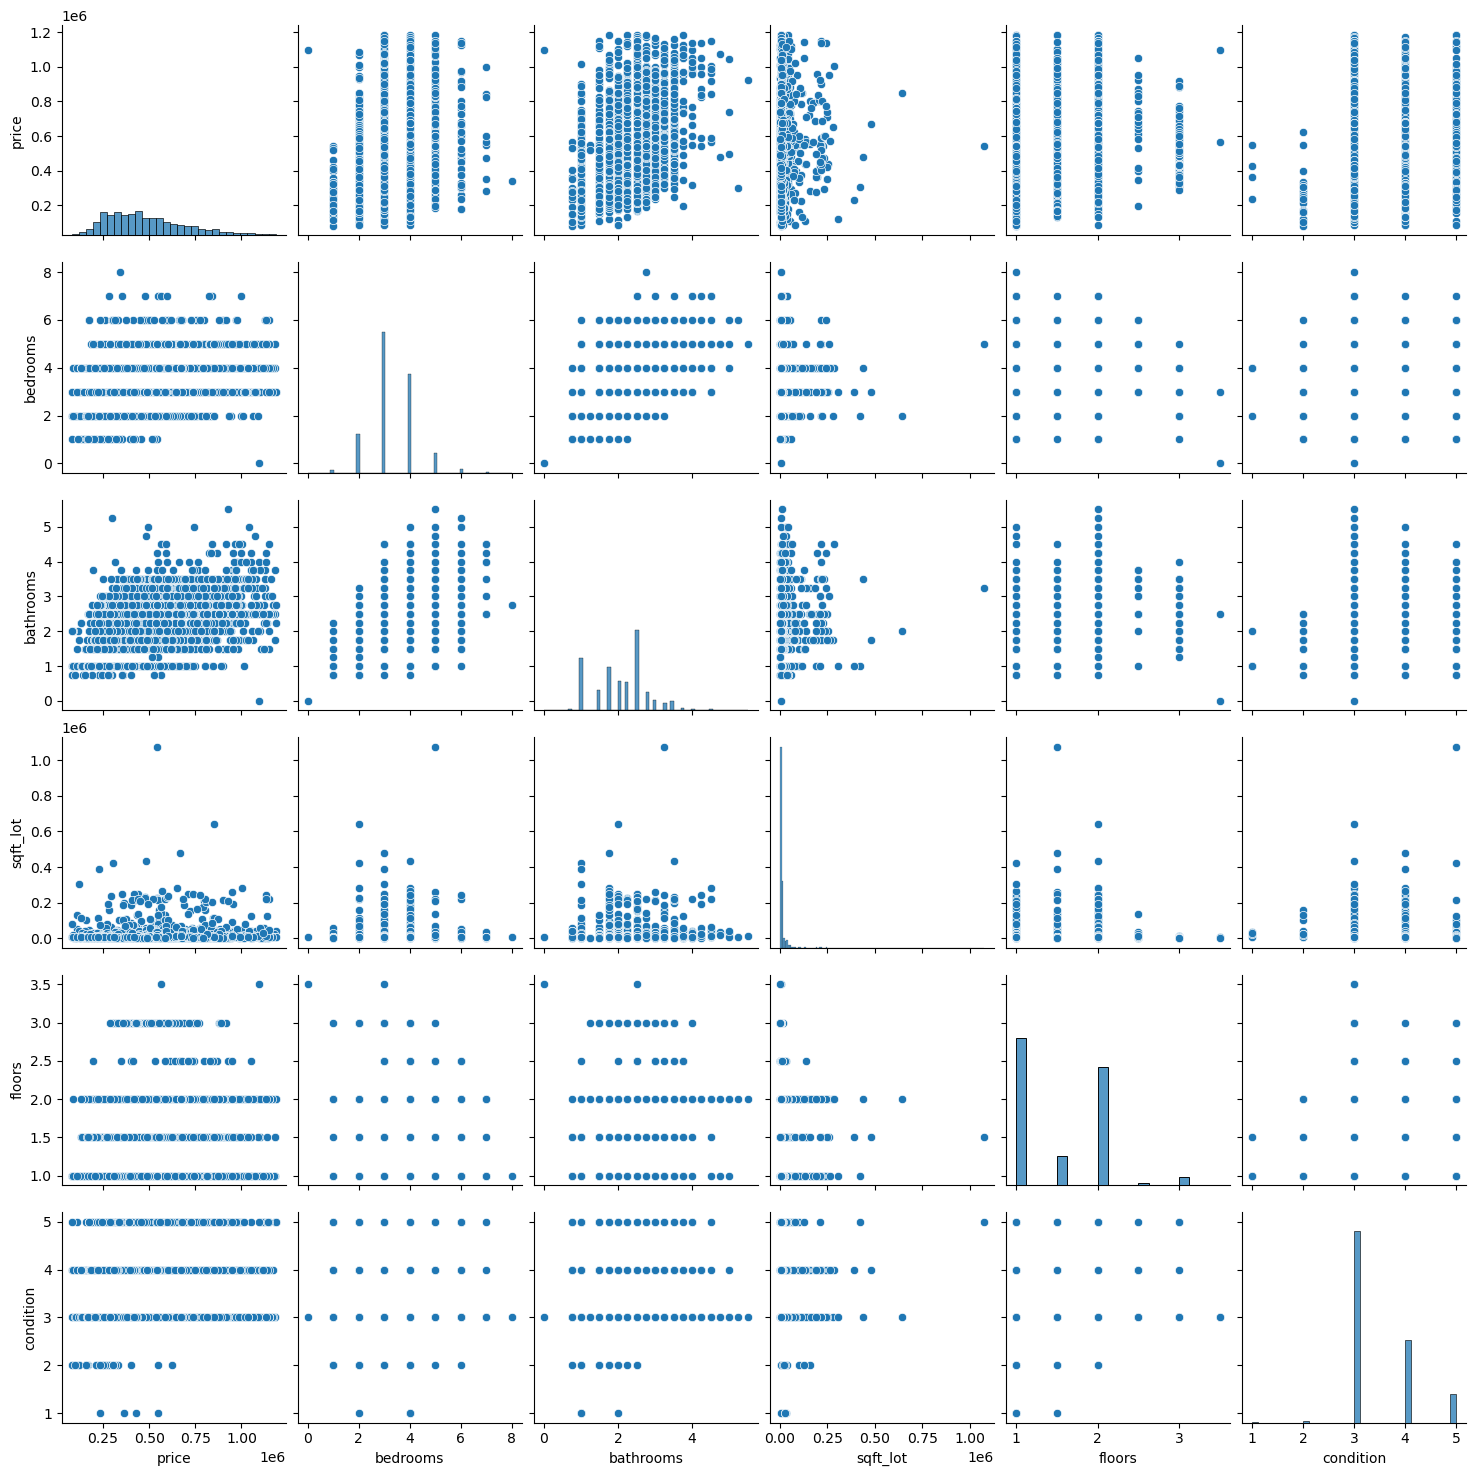

In [38]:
import seaborn as sns

sns.pairplot(dataFiltered, height = 2.5)
plt.show()

<Axes: >

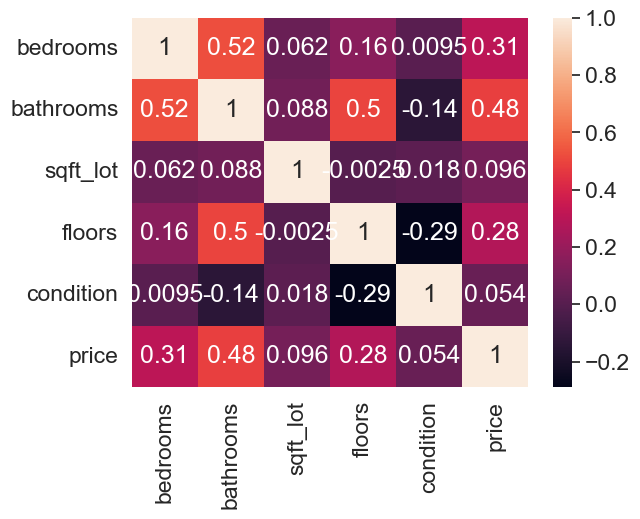

In [39]:
numeric_cols = ["bedrooms", "bathrooms", "sqft_lot", "floors", "condition", "price"]
cm = np.corrcoef(dataFiltered[numeric_cols].values.T)
sns.set(font_scale = 1.5)
sns.heatmap(cm, annot = True, yticklabels = numeric_cols, xticklabels = numeric_cols)

In [40]:
#Codifying Categorical Data
dataFiltered = pd.get_dummies(dataFiltered, columns = ['city'], drop_first = True)
dataFiltered.head(3)

,price,bedrooms,bathrooms,sqft_lot,floors,condition,city_Auburn,city_Beaux Arts Village,city_Bellevue,city_Black Diamond,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,376000.0,3.0,2.00,1384,3.0,3,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,800000.0,4.0,3.25,159430,2.0,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,324000.0,3.0,2.25,904,2.0,3,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [41]:
dataFiltered.to_csv('housing_cleansed.csv', index = False)

In [42]:
#Defining Dependent and Independent Variables
X_cols = list(set(dataFiltered.columns) - set(['price']))
y_cols = ['price']

X = dataFiltered[X_cols].values
y = dataFiltered[y_cols].values

In [43]:
#Splitting the Data Set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [44]:
#Scaling variables
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [46]:
#Adjusting the model to the Data Set
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
#Predicting using Testing Set
y_pred = regression.predict(X_test)

In [48]:
#Evaluating Metrics
import sklearn.metrics as metrics
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test,y_pred)

print("MSE: ", mse)
print("R2: ", r2)

MSE:  21887841847.823227
R2:  0.5433982995999558


In [49]:
pd.options.display.float_format = '{:,.0f}'.format
dataFiltered.price.describe()

count       3,883
mean      489,711
std       219,934
min        80,000
25%       320,000
50%       450,000
75%       620,000
max     1,185,001
Name: price, dtype: float64

In [50]:
rmse = np.sqrt(mse)
rmse.round(4)

np.float64(147945.4016)

In [51]:
np.mean(y_test)

np.float64(487148.90959537704)

In [52]:
print("Type: ", type(y_test))
print("Shape: ", y_test.shape)

Type:  <class 'numpy.ndarray'>
Shape:  (777, 1)


In [53]:
real_relative_error = 147945 / 487148
real_relative_error

0.30369620731276736

In [54]:
residual_error = 147945.4016 / 489711
residual_error

0.30210757283377343

In [55]:
import statsmodels.api as sm

print("Regression.intercept_ type: ", type(regression.intercept_))
print("Regression.intercept_ shape: ", regression.intercept_.shape)

Regression.intercept_ type:  <class 'numpy.ndarray'>
Regression.intercept_ shape:  (1,)


In [56]:
regression.intercept_

array([490352.50075805])

In [57]:
print("Regression.coef_ type: ", type(regression.coef_))
print("Regression.coef_ shape: ", regression.coef_.shape)

Regression.coef_ type:  <class 'numpy.ndarray'>
Regression.coef_ shape:  (1, 47)


In [58]:
regression.coef_

array([[ 17015.16536694,   7143.2530301 ,  19381.16467348,
          3605.99614497,    352.9011029 ,  14645.1107936 ,
         61380.88695782,  24515.39773008,   7811.70717643,
         -2790.52967393,  20118.83775994, 138442.97897245,
         28666.7470613 ,  14986.99741297,    229.35477293,
          7968.72997253,   5601.49555115,  18767.00464947,
         11927.51120094,  12123.51543692,   6688.94700947,
         19714.54116856,  78847.08862233,   1652.55412613,
          5078.84836117,  49070.24931782,  20029.08933716,
         71757.52857914,  47390.39354169,  10785.3398704 ,
         10528.83369306,   7126.22539979,  33469.27917446,
         22794.57646804,  79091.88765836,  15639.38310309,
          4937.99678741,  16670.32118681,  93526.02701068,
         30067.08286447,   8061.20965603,   9656.35627086,
          1980.25741365,  61587.88517638,  23916.9030492 ,
             0.        ,   9690.36547339]])

In [59]:
print("y_test type: ", type(y_test))
print("y_test shape: ", y_test.shape)

y_test type:  <class 'numpy.ndarray'>
y_test shape:  (777, 1)


In [60]:
print("Regression.coef_shape: ", regression.coef_.reshape(-1).shape)

Regression.coef_shape:  (47,)


In [61]:
print("y_test type: ", type(y_test))
print("y_test shape: ", y_test.reshape(-1).shape)

y_test type:  <class 'numpy.ndarray'>
y_test shape:  (777,)


In [62]:
#Backward Elimination
import statsmodels.api as sm

X_df = pd.DataFrame(X_train, columns=X_cols)
X_df = sm.add_constant(X_df)

model = sm.OLS(y_train, X_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     78.04
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        20:23:53   Log-Likelihood:                -41412.
No. Observations:                3106   AIC:                         8.292e+04
Df Residuals:                    3059   BIC:                         8.320e+04
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    4

In [63]:
X_be = pd.DataFrame(X_train, columns = X_cols)
X_be = sm.add_constant(X_be)
y_be = y_train.ravel()

SL = 0.05

while True:
    model = sm.OLS(y_be, X_be).fit()
    pvalues = model.pvalues

    max_p = pvalues.max()

    if max_p > SL:
        worst_feature = pvalues.idxmax()

        if worst_feature == 'const':
            break

        X_be = X_be.drop(columns=[worst_feature])
        print(f"Removed: {worst_feature} (p={max_p})")

    else:
        break

Removed: city_Pacific (p=0.9696810798668813)
Removed: city_Skykomish (p=0.9297430663126731)
Removed: city_Covington (p=0.8864147484306881)
Removed: city_Milton (p=0.5675345455964771)
Removed: city_Kent (p=0.568778211909682)
Removed: city_Enumclaw (p=0.7220158217717652)
Removed: city_Federal Way (p=0.6652583171176127)
Removed: city_Auburn (p=0.749548344604881)
Removed: city_SeaTac (p=0.4576157190352307)
Removed: city_Maple Valley (p=0.4477533190397418)
Removed: city_Tukwila (p=0.41890865772488395)
Removed: city_Medina (p=0.19228957566551977)
Removed: city_Preston (p=0.149544733488618)


In [64]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     108.8
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        20:23:53   Log-Likelihood:                -41415.
No. Observations:                3106   AIC:                         8.290e+04
Df Residuals:                    3072   BIC:                         8.310e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    4